# IMPLEMENTASI PELATIHAN MODEL

Notebook ini digunakan untuk melakukan proses pelatihan model klasifikasi sentimen menggunakan algoritma Naïve Bayes. Tahapan meliputi pelabelan sentimen, pembobotan TF-IDF, pembagian data latih dan data uji, pelatihan model, evaluasi menggunakan Confusion Matrix, serta penyimpanan model yang telah dilatih.

In [1]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [2]:
from nltk.tokenize import word_tokenize
import nltk
nltk.download("punkt")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [3]:
df = pd.read_excel("../dataset/label_manual.xlsx")
df

,komentar,sentimen
0,era keganasan john herdman,positif
1,john herdman out,negatif
2,dihancurkan si patrick dibangun john herdman,positif
3,kalau pendapat berikan kesempatan coach john h...,positif
4,tetap john herdman baru awal latih cari gaya p...,positif
...,...,...
3003,sama coach,positif
3004,kasih terbaik pertandingan,positif
3005,timnas jelek,negatif
3006,john out,negatif


In [4]:
print("Jumlah Dataset :", len(df))
print()

print("Distribusi Sentimen:")
print(df["sentimen"].value_counts())

Jumlah Dataset : 3008

Distribusi Sentimen:
sentimen
netral     1342
positif    1093
negatif     573
Name: count, dtype: int64


# IMPLEMENTASI PELATIHAN MODEL

Notebook ini digunakan untuk melakukan proses pelatihan model klasifikasi sentimen menggunakan algoritma Multinomial Naïve Bayes. Tahapan yang dilakukan meliputi pemuatan dataset berlabel, pembobotan TF-IDF, pembagian data latih dan data uji, pelatihan model, evaluasi model, serta penyimpanan model yang telah dilatih.

In [5]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

## Pemisahan Data dan Label

Pada tahap ini dataset dipisahkan menjadi data komentar sebagai fitur (X) dan label sentimen sebagai target (y). Pemisahan ini dilakukan sebelum proses pembobotan TF-IDF dan pelatihan model.

In [6]:
X = df["komentar"]

y = df["sentimen"]

print("Jumlah Data Komentar :", len(X))
print("Jumlah Label :", len(y))

Jumlah Data Komentar : 3008
Jumlah Label : 3008


In [7]:
# ==========================================
# TF-IDF
# ==========================================

tfidf = TfidfVectorizer(

    ngram_range=(1,2),
    min_df=3,
    max_df=0.85,
    sublinear_tf=True

)

X = tfidf.fit_transform(df["komentar"])

y = df["sentimen"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Jumlah Data Training :", len(y_train))
print("Jumlah Data Testing :", len(y_test))

Jumlah Data Training : 2406
Jumlah Data Testing : 602


In [9]:
import pandas as pd

# Distribusi sentimen data uji
distribusi_test = pd.Series(y_test).value_counts()

print("Distribusi Sentimen Data Uji")
print(distribusi_test)

Distribusi Sentimen Data Uji
sentimen
netral     268
positif    219
negatif    115
Name: count, dtype: int64


In [10]:
# Mengubah hasil TF-IDF menjadi DataFrame

tfidf_df = pd.DataFrame(

    X.toarray(),

    columns=tfidf.get_feature_names_out()

)

tfidf_df.head()

,abiie,abis,abis hattrick,abroad,absen,acak,acara,ad,adaptasi,adem,...,yoi,yok,you,you coach,you guys,your,yu,yuk,zaman,zonk
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Pelatihan Model Naïve Bayes

Tahap ini melakukan proses pelatihan model menggunakan algoritma Naïve Bayes.

In [11]:
model = MultinomialNB(alpha=0.1)

model.fit(X_train, y_train)

print("Training Model Berhasil")

Training Model Berhasil


## Penyimpanan Model

Setelah proses pelatihan selesai, model Multinomial Naïve Bayes dan objek TF-IDF disimpan ke dalam file berekstensi .pkl sehingga dapat digunakan kembali pada proses klasifikasi tanpa perlu melakukan pelatihan ulang.

In [12]:
import joblib

joblib.dump(
    model,
    "../model/model_naive_bayes.pkl"
)

joblib.dump(
    tfidf,
    "../model/tfidf.pkl"
)

print("Model berhasil disimpan")
print("TF-IDF berhasil disimpan")

Model berhasil disimpan
TF-IDF berhasil disimpan


## Evaluasi Model

Model yang telah dilatih kemudian diuji menggunakan data testing untuk mengetahui tingkat akurasi klasifikasi sentimen.

In [13]:
y_pred = model.predict(X_test)

In [14]:
from sklearn.metrics import accuracy_score

akurasi = accuracy_score(
    y_test,
    y_pred
)

print("Akurasi :", round(akurasi*100,2), "%")

Akurasi : 80.4 %


In [15]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

     negatif       0.74      0.63      0.68       115
      netral       0.82      0.87      0.84       268
     positif       0.81      0.82      0.81       219

    accuracy                           0.80       602
   macro avg       0.79      0.77      0.78       602
weighted avg       0.80      0.80      0.80       602



In [16]:
from sklearn.metrics import confusion_matrix

labels = ["positif", "netral", "negatif"]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

cm

array([[179,  26,  14],
       [ 24, 233,  11],
       [ 18,  25,  72]])

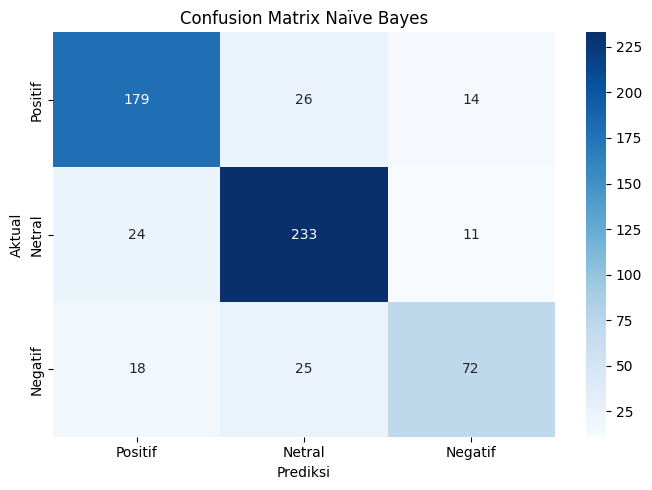

confusion_matrix.png berhasil disimpan


In [17]:
import os
import seaborn as sns

os.makedirs("assets/images", exist_ok=True)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Positif","Netral","Negatif"],
    yticklabels=["Positif","Netral","Negatif"]
)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix Naïve Bayes")

plt.tight_layout()

plt.savefig(
    "../static/images/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("confusion_matrix.png berhasil disimpan")

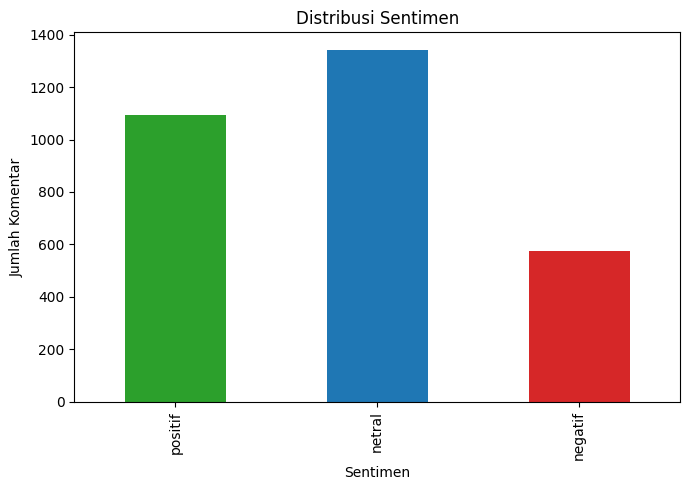

distribusi_sentimen_bar.png berhasil disimpan


In [19]:
sentimen_count = (
    df["sentimen"]
    .value_counts()
    .reindex(["positif", "netral", "negatif"], fill_value=0)
)

warna = {
    "positif": "#2ca02c",   # hijau
    "netral": "#1f77b4",    # biru
    "negatif": "#d62728"    # merah
}

plt.figure(figsize=(7,5))

sentimen_count.plot(
    kind="bar",
    color=[warna[label] for label in sentimen_count.index]
)

plt.title("Distribusi Sentimen")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Komentar")

plt.tight_layout()

plt.savefig(
    "../static/images/distribusi_sentimen_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("distribusi_sentimen_bar.png berhasil disimpan")

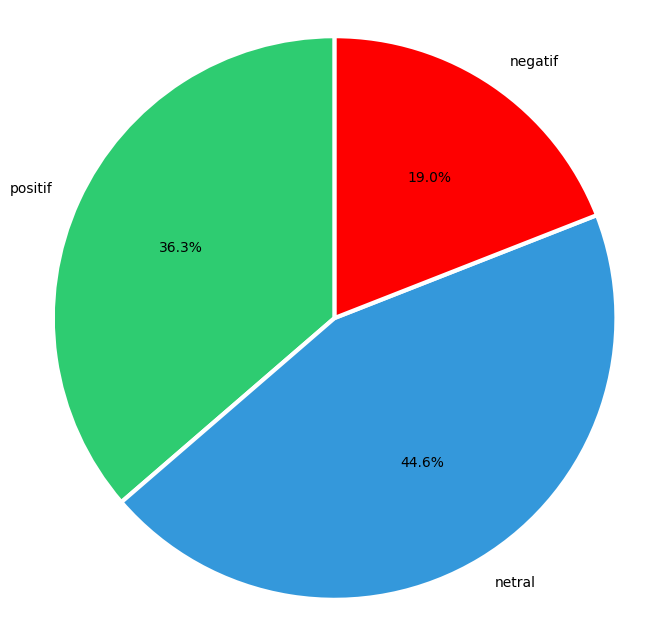

In [37]:
import matplotlib.pyplot as plt

# Hitung jumlah tiap kelas
sentimen_count = df["sentimen"].value_counts()

# Urutkan agar Positif, Netral, Negatif
sentimen_count = sentimen_count.reindex(
    ["positif", "netral", "negatif"]
)

# Warna untuk masing-masing kelas
warna = [
    "#2ecc71",  # Positif (Hijau)
    "#3498db",  # Netral (Biru)
    "#e74c3c"   # Negatif (Merah)
]

# Ukuran gambar
colors = [
    "#2ecc71",   # Positif (Hijau)
    "#3498db",   # Netral (Biru)
    "#fe0000"    # Negatif (Merah)
]

plt.figure(figsize=(8,8))

plt.pie(
    sentimen_count,
    labels=sentimen_count.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={
        "edgecolor":"white",
        "linewidth":3
    }
)

plt.axis("equal")

plt.savefig(
    "../static/images/distribusi_sentimen_pie.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.show()

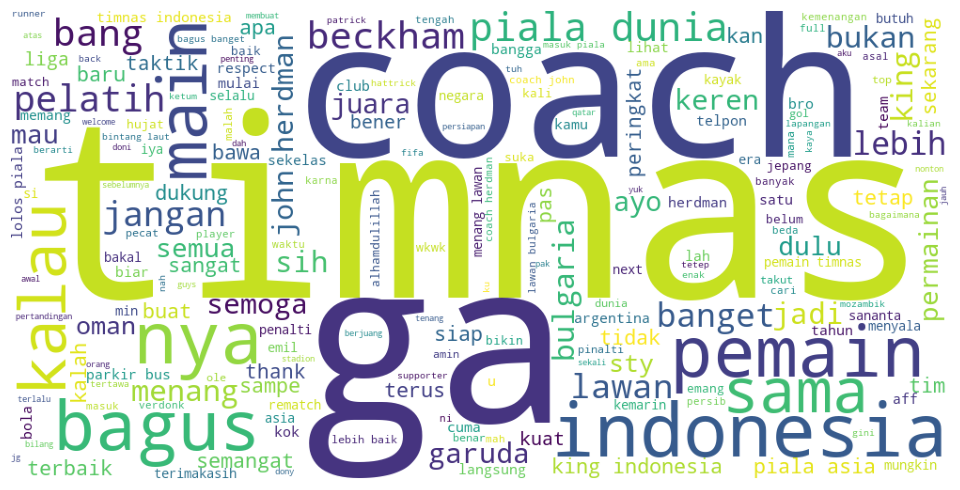

wordcloud_positif.png berhasil disimpan


In [29]:
from wordcloud import WordCloud

positif = " ".join(
    df[df["sentimen"]=="positif"]["komentar"]
    .astype(str)
)

wc = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(positif)

plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis("off")

plt.tight_layout()

plt.savefig(
    "../static/images/wordcloud_positif.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("wordcloud_positif.png berhasil disimpan")

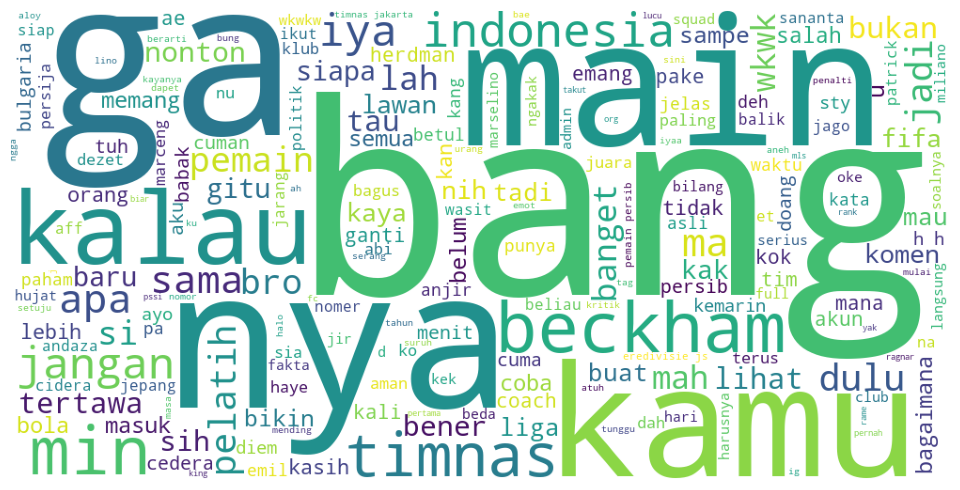

wordcloud_netral.png berhasil disimpan


In [30]:
netral = " ".join(
    df[df["sentimen"]=="netral"]["komentar"]
    .astype(str)
)

wc = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(netral)

plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis("off")

plt.tight_layout()

plt.savefig(
    "../static/images/wordcloud_netral.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("wordcloud_netral.png berhasil disimpan")

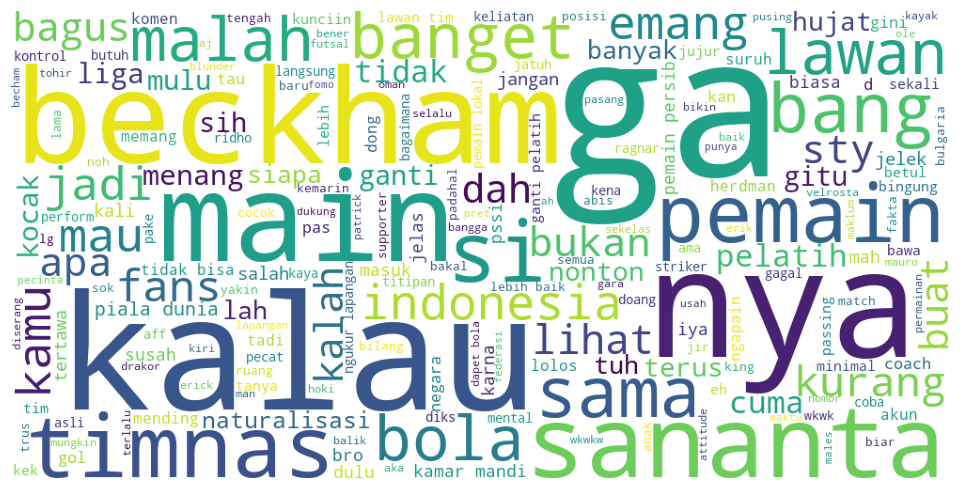

wordcloud_negatif.png berhasil disimpan


In [31]:
negatif = " ".join(
    df[df["sentimen"]=="negatif"]["komentar"]
    .astype(str)
)

wc = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(negatif)

plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis("off")

plt.tight_layout()

plt.savefig(
    "../static/images/wordcloud_negatif.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("wordcloud_negatif.png berhasil disimpan")

In [32]:
prediksi = model.predict(X)

hasil = pd.DataFrame({
    "komentar": df["komentar"],
    "label asli": df["sentimen"],
    "hasil prediksi": prediksi
})

hasil["status"] = hasil.apply(
    lambda x: "Benar"
    if x["label asli"] == x["hasil prediksi"]
    else "Salah",
    axis=1
)

hasil.to_excel(
    "../dataset/hasil_prediksi_naive_bayes.xlsx",
    index=False
)

print("hasil_prediksi_naive_bayes.xlsx berhasil dibuat")

hasil_prediksi_naive_bayes.xlsx berhasil dibuat


In [ ]:
hasil.head()

,komentar,label asli,hasil prediksi,status
0,era keganasan john herdman,positif,positif,Benar
1,john herdman out,negatif,negatif,Benar
2,dihancurkan si patrick dibangun john herdman,positif,positif,Benar
3,kalau pendapat berikan kesempatan coach john h...,positif,positif,Benar
4,tetap john herdman baru awal latih cari gaya p...,positif,positif,Benar
